In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score

In [48]:
df=pd.read_csv("C:\\Users\\banup\\OneDrive\\Desktop\\Fitbit project3\\Fitbit_dataset.csv")

In [49]:
df.head()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [50]:
df.shape

(14102, 19)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  str    
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  str    
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null  int64  
 1

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df = df.drop(columns=["Unnamed: 0"])
df1=df.copy()

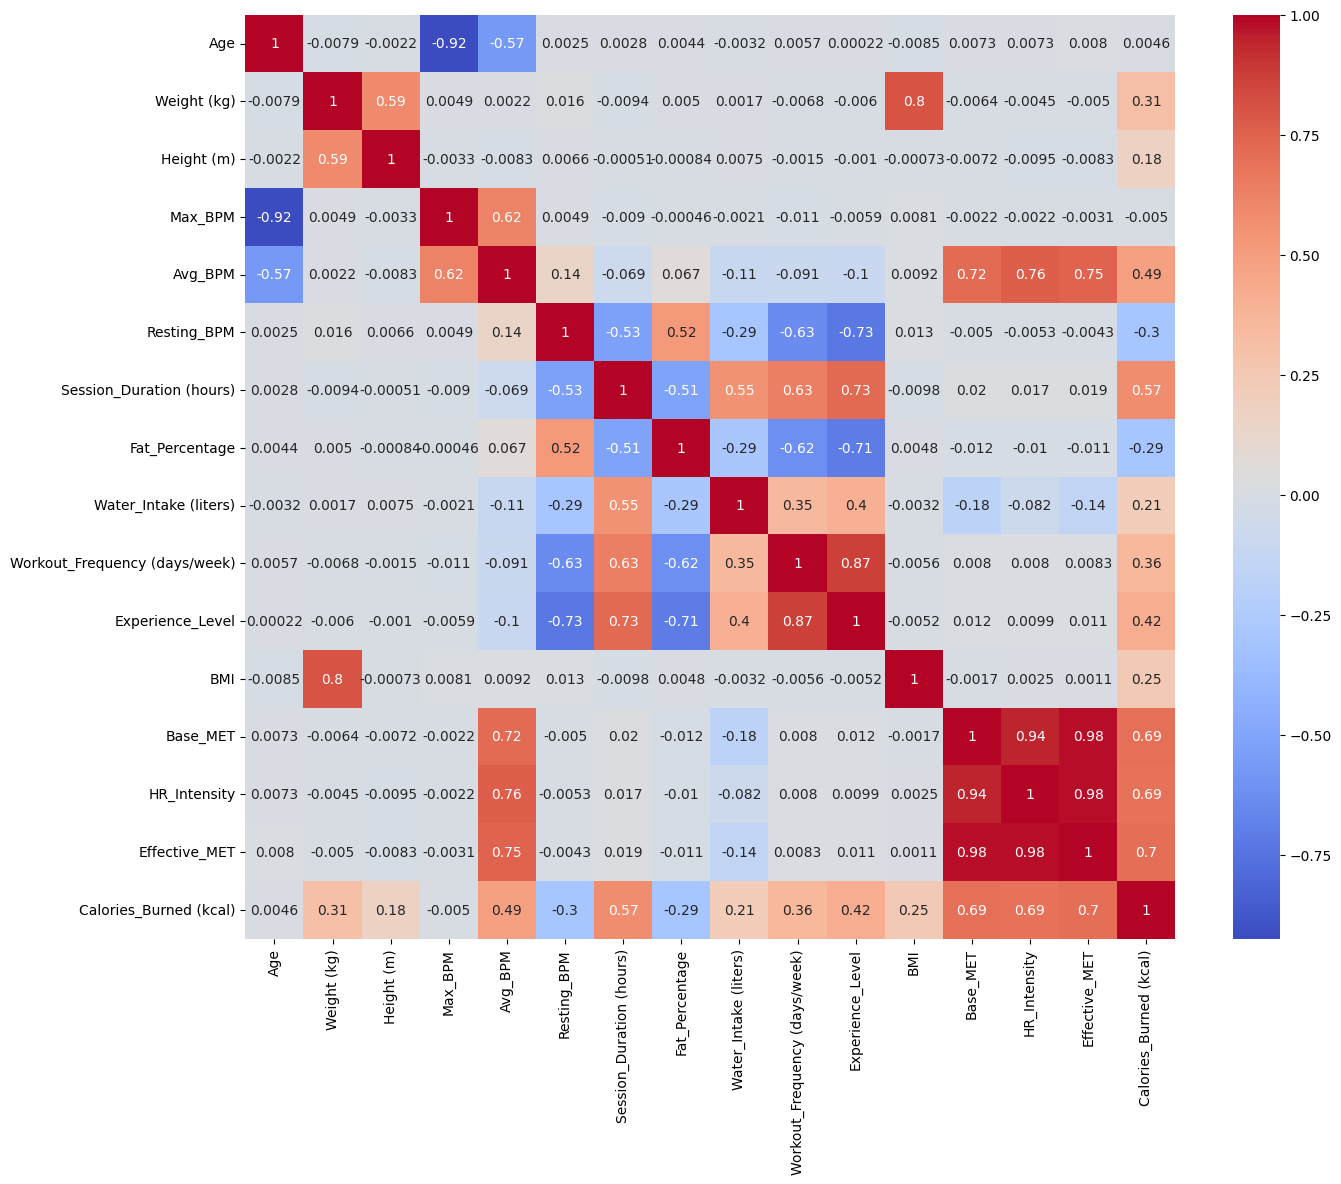

In [54]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",annot=True)
plt.show()

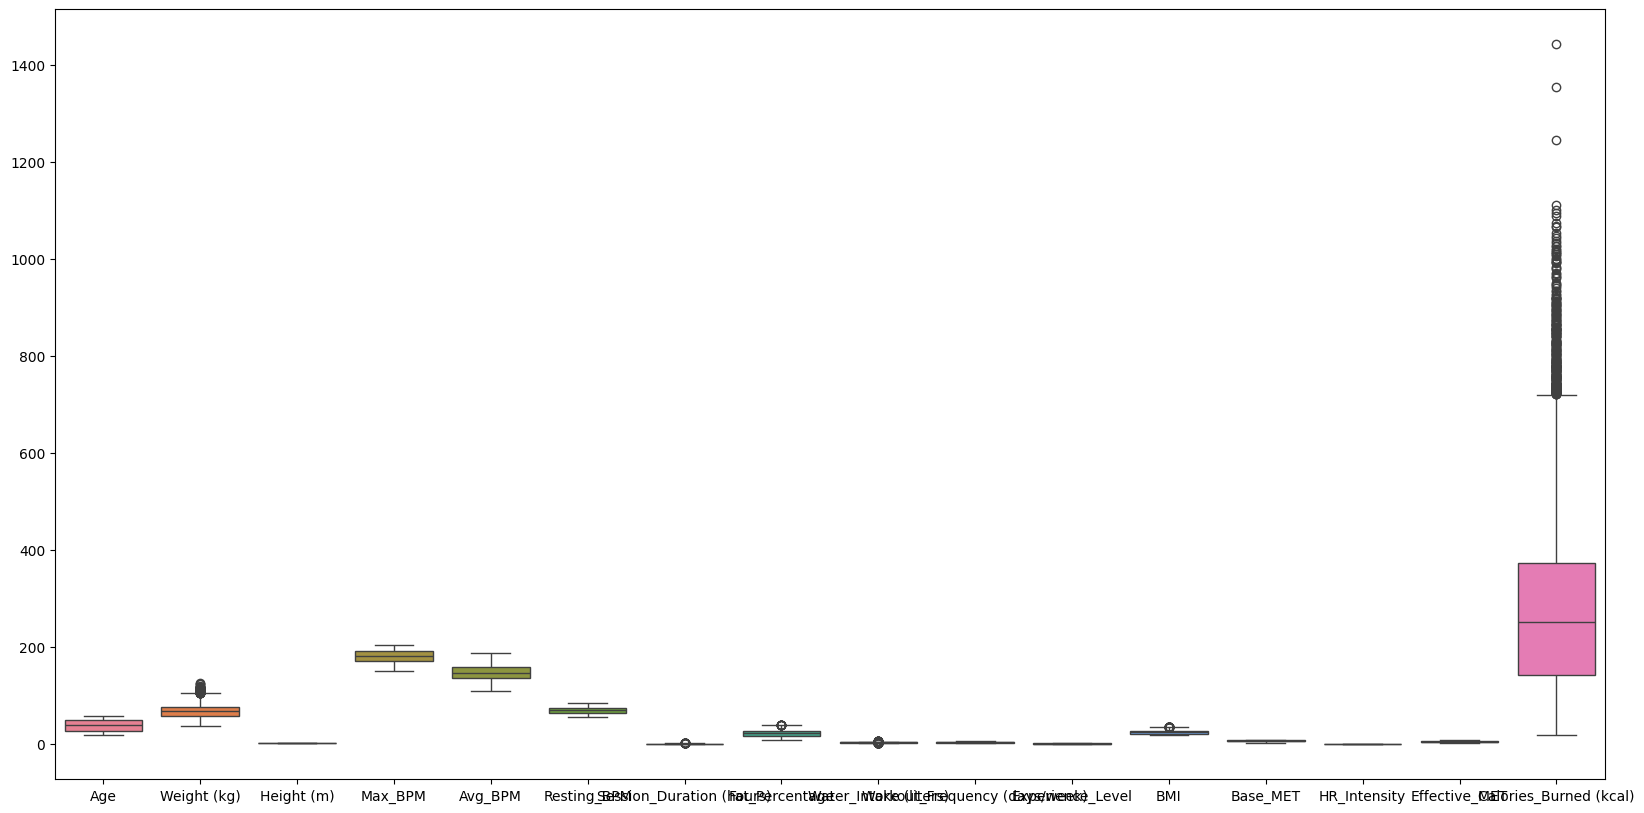

In [55]:
#Outlier Detection
plt.figure(figsize=(20,10), facecolor='w')
sns.boxplot(data=df)
plt.show()

In [56]:
#Winsorizing
numeric_cols=df.select_dtypes(include="number")
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df[numeric_cols.columns] = numeric_cols.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [57]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


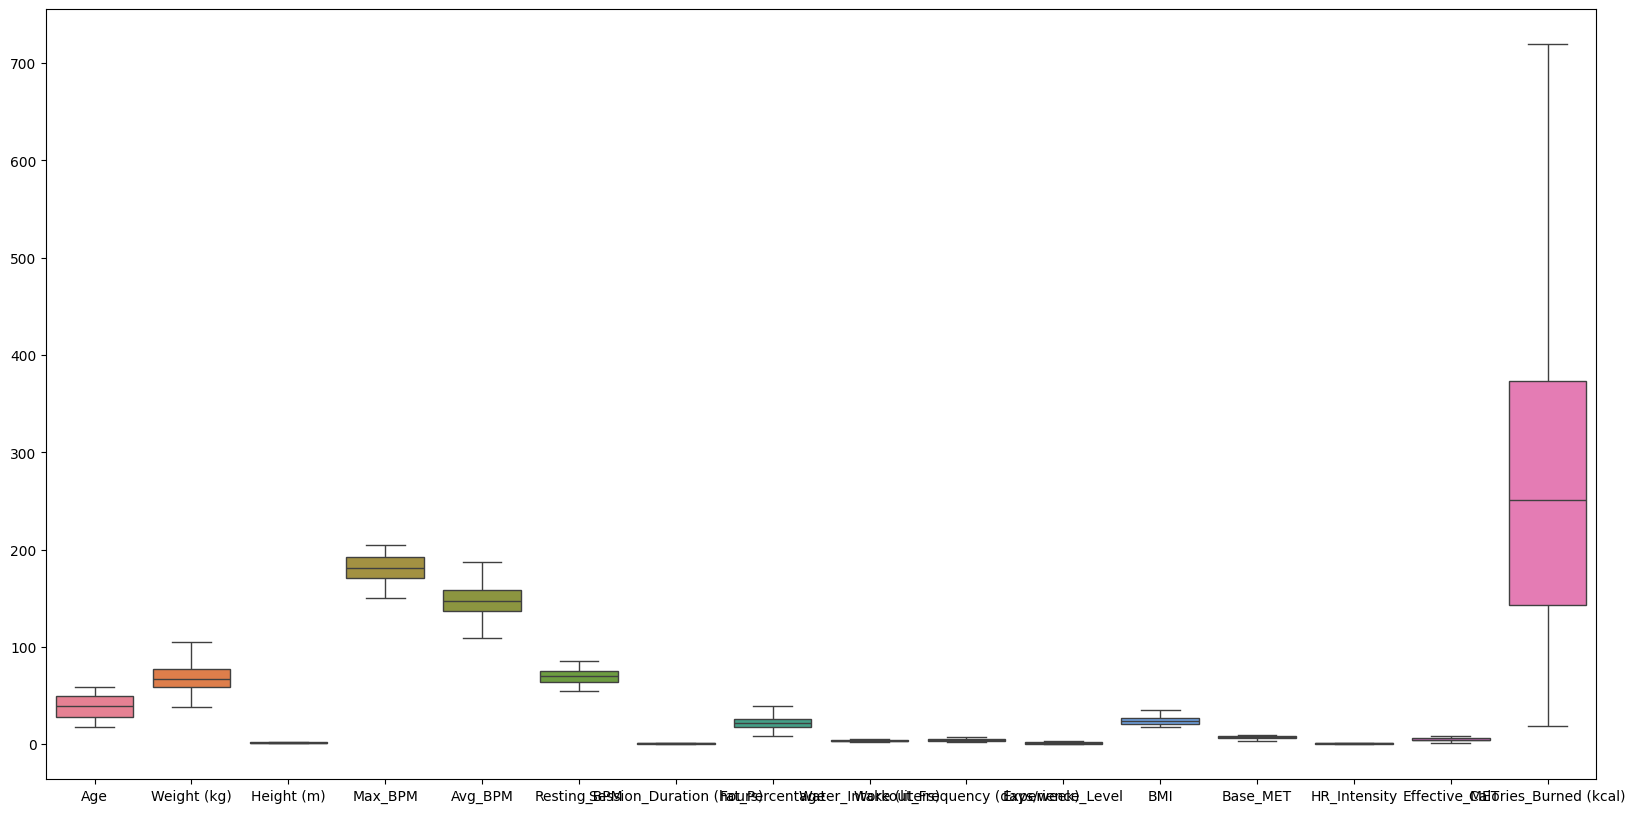

In [58]:
plt.figure(figsize=(20,10), facecolor='w')
sns.boxplot(data=df)
plt.show()

In [59]:
#Encode Categorical Variables
label_encoder=LabelEncoder()
df["Gender"]=label_encoder.fit_transform(df["Gender"])

In [60]:
one_hot_encoder=OneHotEncoder(sparse_output=False)
ohe=one_hot_encoder.fit_transform(df[["Workout_Type"]])
encoded_df = pd.DataFrame(ohe, columns=one_hot_encoder.get_feature_names_out(["Workout_Type"]))
df = pd.concat([df.drop(columns=["Workout_Type"]), encoded_df], axis=1)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),...,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Mixed,Workout_Type_Strength,Workout_Type_Yoga
0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,...,20.4,9.5,0.847826,8.054348,437.7,0.0,1.0,0.0,0.0,0.0
1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,...,18.0,3.0,0.546392,1.639175,22.5,0.0,0.0,0.0,0.0,1.0
2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,...,26.5,9.5,0.853846,8.111538,183.4,0.0,1.0,0.0,0.0,0.0
3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,...,28.5,3.0,0.550000,1.650000,127.2,0.0,0.0,0.0,0.0,1.0
4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,...,32.5,7.0,0.654545,4.581818,240.7,1.0,0.0,0.0,0.0,0.0


In [61]:
#scaling
scaler = StandardScaler()
X = df.drop("Calories_Burned (kcal)", axis=1)
Y = df["Calories_Burned (kcal)"]
X_scaled = scaler.fit_transform(X)

In [62]:
#Split test and train from scaled data
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,Y,test_size=0.2,random_state=42)

In [63]:
#Supervised Learning Models - Regression
#Regression with scaling
def reg_model(model,X_train,Y_train,X_test,Y_test,name="Model"):
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_test)
    print(f"{name}")
    print(f"MAE:{mean_absolute_error(Y_test, y_pred):.2f}")
    print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, y_pred)):.2f}")
    print(f"R2:{r2_score(Y_test, y_pred):.2f}")
    print()

reg_model(LinearRegression(),X_train,Y_train,X_test,Y_test,"Linear Regression")
reg_model(Ridge(alpha=1.0),X_train,Y_train,X_test,Y_test,"Ridge Regression")
reg_model(Lasso(alpha=0.1),X_train,Y_train,X_test,Y_test,"Lasso Regression")
reg_model(KNeighborsRegressor(n_neighbors=5),X_train,Y_train,X_test,Y_test,"KNeighbours Regression")
reg_model(SVR(kernel='rbf'),X_train,Y_train,X_test,Y_test,"SVR")

Linear Regression
MAE:31.76
RMSE:45.72
R2:0.93

Ridge Regression
MAE:31.76
RMSE:45.72
R2:0.93

Lasso Regression
MAE:31.72
RMSE:45.70
R2:0.93

KNeighbours Regression
MAE:28.28
RMSE:39.29
R2:0.95

SVR
MAE:27.88
RMSE:47.50
R2:0.92



In [64]:
#Regression without scaling
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

def regg_model(model,X_train,Y_train,X_test,Y_test,name="Model"):
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_test)
    print(f"{name}")
    print(f"MAE:{mean_absolute_error(Y_test, y_pred):.2f}")
    print(f"RMSE:{np.sqrt(mean_squared_error(Y_test, y_pred)):.2f}")
    print(f"R2:{r2_score(Y_test, y_pred):.2f}")
    print()

regg_model(DecisionTreeRegressor(max_depth=3,random_state=42),X_train,Y_train,X_test,Y_test,"Decision Tree")
regg_model(RandomForestRegressor(max_depth=3,n_estimators=100,random_state=42),X_train,Y_train,X_test,Y_test,"Random Forest")
regg_model(XGBRegressor(random_state=42),X_train,Y_train,X_test,Y_test,"XGBOOST")

Decision Tree
MAE:59.44
RMSE:79.30
R2:0.78

Random Forest
MAE:56.04
RMSE:74.81
R2:0.80

XGBOOST
MAE:5.13
RMSE:7.81
R2:1.00



In [65]:
#Evaluvation for Supervised models
Outcome={
    "Model": ["Linear Regression","Ridge","Lasso","KNN","SVR","Decision Tree","Random Forest","XGBoost"],
    "MAE": [31.76,31.76,31.72,28.28,27.88,59.44,56.04,5.13],
    "RMSE": [45.72,45.72,45.70,39.29,47.50,79.30,74.81,7.81],
    "R2": [0.93,0.93,0.93,0.95,0.92,0.78,0.80,1.00]
}
df_outcome= pd.DataFrame(Outcome)

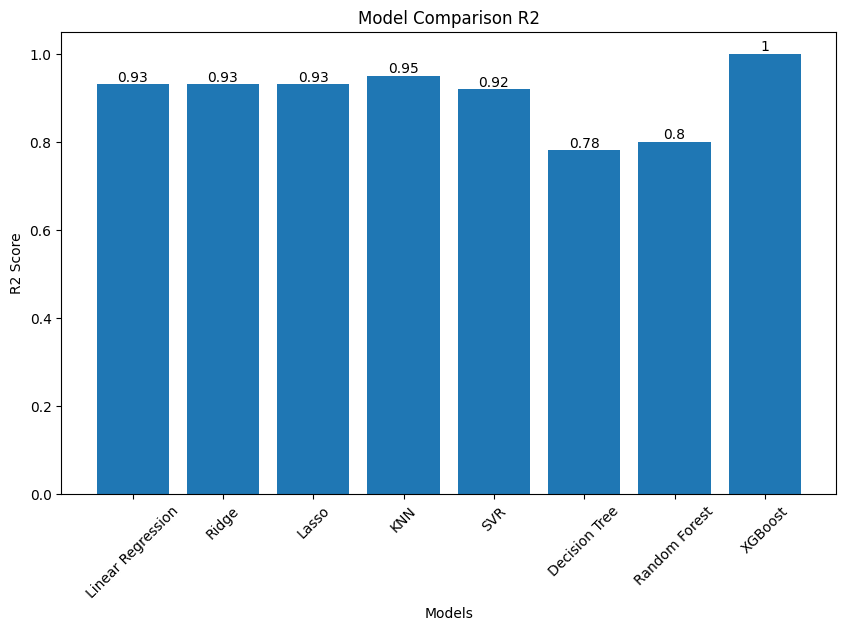

In [66]:
#Visualization of R2 score
plt.figure(figsize=(10,6))
bars=plt.bar(df_outcome["Model"], df_outcome["R2"])
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison R2")
plt.tick_params(axis='x', rotation=45)
plt.bar_label(bars)
plt.show()

In [67]:
#Unsupervised Learning Models
#Drop target variable
df1=df1.drop(["Workout_Type"],axis=1)
df1.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [68]:
#Encoding
label_encoder=LabelEncoder()
df1["Gender"]=label_encoder.fit_transform(df1["Gender"])

In [69]:
#Scaling
scaler = StandardScaler()
scaled_data=scaler.fit_transform(df1)
df1_scaled =pd.DataFrame(scaled_data, columns=df1.columns)
df1_scaled.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,1.455052,-1.010121,-1.084252,-0.618597,-1.424966,0.071400,0.234450,0.623405,0.042798,-0.157454,-0.697148,-0.142302,-0.977941,1.271842,1.458930,1.473327,0.915274
1,0.622244,0.989981,-1.001730,0.714199,-0.882883,-1.500891,0.515745,-2.010722,-0.325451,-0.317104,-0.697148,-1.087537,-1.613511,-1.709308,-1.547608,-1.546762,-1.486777
2,-0.543688,-1.010121,0.018536,-0.721120,0.665927,1.575330,-1.312677,-1.733445,-0.241758,-1.434656,-0.697148,-0.142302,0.637467,1.271842,1.518975,1.500251,-0.555925
3,-1.126653,0.989981,2.291628,1.841950,0.588486,-0.885647,-0.046846,-0.173765,1.415364,1.279399,-0.697148,-1.087537,1.167109,-1.709308,-1.511619,-1.541666,-0.881058
4,-0.044003,0.989981,2.044063,0.304108,-0.418240,-0.680565,-0.468790,-0.970935,0.310616,-2.232908,-1.303225,-1.087537,2.226392,0.125246,-0.468871,-0.161446,-0.224428


In [70]:
#PCA for Dimensionality Reduction
pca=PCA(n_components=2) 
pca_data = pca.fit_transform(scaled_data)
print("variance ration:",pca.explained_variance_ratio_)

variance ration: [0.25657577 0.23127937]


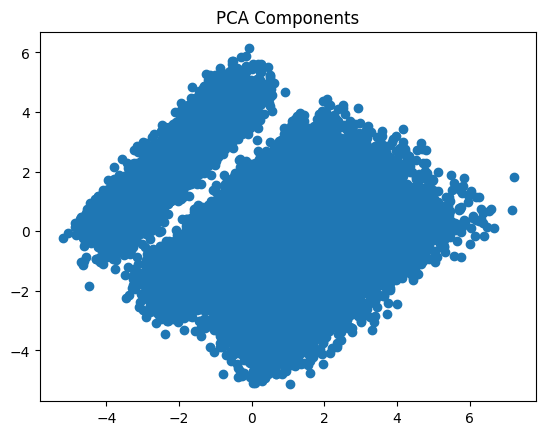

In [71]:
plt.scatter(pca_data[:,0],pca_data[:,1])
plt.title("PCA Components")
plt.show()

In [72]:
best_k=0
best_score=-1
scores=[]
for k in range(2,10):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(pca_data)
    score=silhouette_score(pca_data,labels)
    scores.append(score)
    if score>best_score:
        best_score=score
        best_k=k

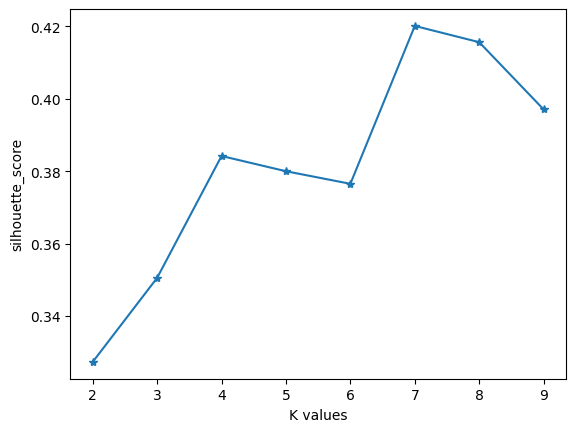

In [73]:

plt.plot(range(2,10),scores,marker='*')
plt.xlabel("K values")
plt.ylabel("silhouette_score")
plt.show()

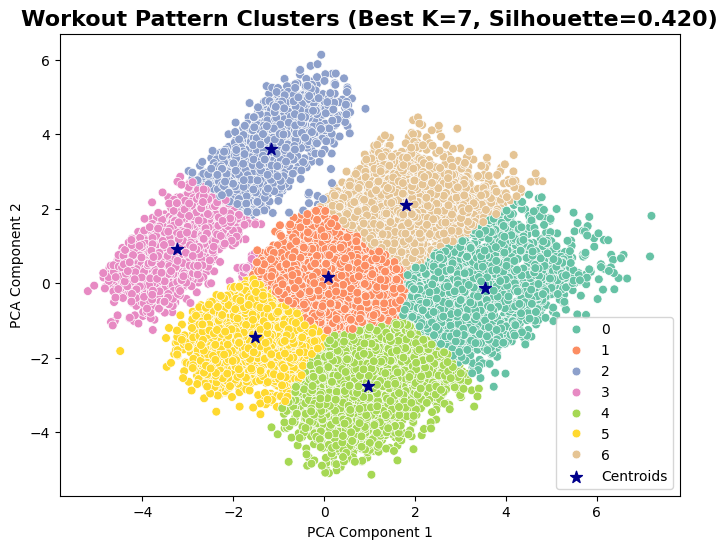

In [74]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(pca_data)
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0], 
    y=pca_data[:,1], 
    hue=labels,  
    palette="Set2", 
    s=40
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:,0], 
    kmeans.cluster_centers_[:,1], 
    c="darkblue", 
    s=80, 
    marker="*", 
    label="Centroids"
)

plt.title(
    f"Workout Pattern Clusters (Best K={best_k}, Silhouette={best_score:.3f})", 
    fontsize=16, fontweight="bold"
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [75]:
results={}
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(pca_data)
results['KMeans'] = silhouette_score(pca_data, kmeans_labels)

In [76]:
hc = AgglomerativeClustering(n_clusters=best_k)
hc_labels = hc.fit_predict(pca_data)
results['Hierarchical'] = silhouette_score(pca_data, hc_labels)

In [77]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(pca_data)

if len(set(db_labels)) > 1:
    results['DBSCAN'] = silhouette_score(pca_data, db_labels)
else:
    results['DBSCAN'] = None

In [78]:
print("Silhouette Scores Comparison:")
for method, score in results.items():
    if score is not None and score != -1:
        print(f"{method}: {score:.3f}")
    else:
        print(f"{method}: Not applicable")


Silhouette Scores Comparison:
KMeans: 0.420
Hierarchical: 0.370
DBSCAN: 0.458


In [ ]:
df1['cluster']=kmeans.labels_
Experience_cluster = df1.groupby(["cluster","Experience_Level"]).size().unstack(fill_value=0)
print(Experience_cluster)

Experience_Level     0     1    2     3
cluster                                
0                    1   223  751   531
1                  147  1980  717     6
2                    0   188  547   403
3                  990   658    9     0
4                 1272   764   35     0
5                 2505   398    0     0
6                    0    13  829  1135


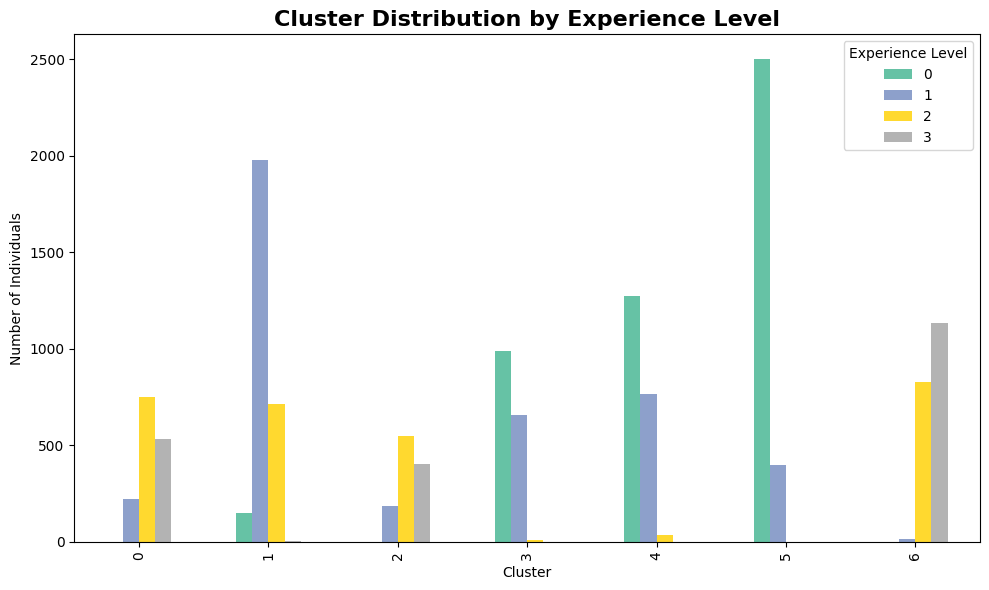

In [81]:
Experience_cluster.plot(kind="bar", figsize=(10,6), colormap="Set2")

plt.title("Cluster Distribution by Experience Level", fontsize=16, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Number of Individuals")
plt.legend(title="Experience Level")
plt.tight_layout()
plt.show()